# Lab 11 Assignment: Anomaly Detection Using GMM — Solution Notebook

**Note:** This notebook provides a complete solution to the assignment. Each question is included as a markdown cell together with the marking scheme. Code cells implement the required steps and produce visualizations. Run the notebook from top to bottom to reproduce results.

---


## Q1. Dataset Loading and Preprocessing (2 Marks)

**Tasks (as in assignment):**

1. Load the Banknote Authentication Dataset from the UCI Machine Learning Repository.
2. Display the first few rows of the dataset and print the feature names.
3. Standardize all feature columns using `StandardScaler`. **(1 Mark)**
4. Show the class distribution of authentic and forged notes using a bar chart. **(1 Mark)**

---


Dataset shape: (1372, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


Feature names: ['variance', 'skewness', 'curtosis', 'entropy']

After standardization: feature means (approx): [ 0.  0.  0. -0.]
After standardization: feature stds (approx): [1. 1. 1. 1.]


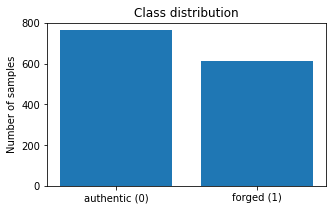

In [ ]:
# Q1: Load dataset, display head, standardize features, show class distribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dataset URL (UCI)
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
cols = ['variance','skewness','curtosis','entropy','class']

# Load dataset
df = pd.read_csv(data_url, header=None, names=cols)
print('Dataset shape:', df.shape)

# Display first few rows
display(df.head())

# Feature names
features = cols[:-1]
print('Feature names:', features)

# Standardize features
scaler = StandardScaler()
X = df[features].values
y = df['class'].values
X_std = scaler.fit_transform(X)

print('\nAfter standardization: feature means (approx):', np.round(X_std.mean(axis=0), 4))
print('After standardization: feature stds (approx):', np.round(X_std.std(axis=0), 4))

# Show class distribution
counts = df['class'].value_counts().sort_index()
plt.figure(figsize=(5,3))
plt.bar(['authentic (0)','forged (1)'], [counts.get(0,0), counts.get(1,0)])
plt.title('Class distribution')
plt.ylabel('Number of samples')
plt.show()


## Data Splitting

Split the dataset into **Training**, **Validation**, and **Test** sets using a **70%-15%-15%** split (random, reproducible). **(1 Mark)**

> Note: The GMM model in later questions should be trained using **only the authentic samples** from the training set.

---


In [ ]:
# Split data into train/val/test (70/15/15)
from sklearn.model_selection import train_test_split

# First split off train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_std, y, train_size=0.70, random_state=RANDOM_STATE, stratify=y)
# Split temp into val and test equally (15% each of total -> each 0.5 of temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print('Shapes:')
print('  Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)

# Show class balance in each set
import numpy as np
print('\nClass counts:')
print(' Train authentic, forged:', np.bincount(y_train))
print(' Val   authentic, forged:', np.bincount(y_val))
print(' Test  authentic, forged:', np.bincount(y_test))


Shapes:
  Train: (960, 4) Validation: (206, 4) Test: (206, 4)

Class counts:
 Train authentic, forged: [533 427]
 Val   authentic, forged: [114  92]
 Test  authentic, forged: [115  91]


## Q2. GMM Implementation from Scratch (4 Mark)

1. Implement the Expectation-Maximization (EM) algorithm for a Gaussian Mixture Model from scratch. (1M)
2. Fit this GMM model using **only the authentic samples** from the training set. **(2 M)**
3. Plot the log-likelihood vs. iteration to demonstrate convergence. **(1 M)**

---


Authentic samples in training set: (533, 4)


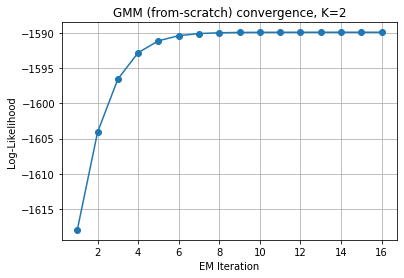

In [ ]:
# Q2: GMM from-scratch implementation (EM)
import numpy as np
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from sklearn.cluster import KMeans

def initialize_gmm_kmeans(X, K, random_state=42):
    kmeans = KMeans(n_clusters=K, random_state=random_state, n_init=10).fit(X)
    pi = np.zeros(K)
    mu = kmeans.cluster_centers_.copy()
    D = X.shape[1]
    sigma = np.zeros((K, D, D))
    labels = kmeans.labels_
    for k in range(K):
        members = X[labels==k]
        pi[k] = max(members.shape[0] / X.shape[0], 1e-8)
        if members.shape[0] > 1:
            sigma[k] = np.cov(members.T) + 1e-6 * np.eye(D)
        else:
            sigma[k] = np.eye(D)
    return pi, mu, sigma

def gmm_em(X, K, max_iters=200, tol=1e-4, verbose=False):
    N, D = X.shape
    pi, mu, sigma = initialize_gmm_kmeans(X, K)
    log_likelihoods = []
    for it in range(max_iters):
        # E-step
        log_resp = np.zeros((N, K))
        for k in range(K):
            try:
                logp = multivariate_normal.logpdf(X, mean=mu[k], cov=sigma[k], allow_singular=True)
            except Exception:
                sigma[k] += 1e-6 * np.eye(D)
                logp = multivariate_normal.logpdf(X, mean=mu[k], cov=sigma[k], allow_singular=True)
            log_resp[:, k] = np.log(pi[k] + 1e-12) + logp
        log_norm = logsumexp(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - log_norm)

        # M-step
        Nk = resp.sum(axis=0)
        pi = Nk / N
        mu = (resp.T @ X) / Nk[:, None]
        sigma_new = np.zeros_like(sigma)
        for k in range(K):
            Xc = X - mu[k]
            weighted = (resp[:, k][:, None] * Xc).T @ Xc
            sigma_new[k] = weighted / Nk[k] + 1e-6 * np.eye(D)
        sigma = sigma_new

        ll = np.sum(log_norm)
        log_likelihoods.append(ll)
        if verbose:
            print(f'Iter {it+1}, ll={ll:.6f}')
        if it>0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
    return {'pi':pi, 'mu':mu, 'sigma':sigma, 'log_likelihoods':log_likelihoods, 'resp':resp}


def gmm_sample_loglikelihoods(X, params):
    pi = params['pi']
    mu = params['mu']
    sigma = params['sigma']
    N = X.shape[0]
    K = pi.shape[0]
    log_comp = np.zeros((N, K))
    for k in range(K):
        log_comp[:, k] = np.log(pi[k] + 1e-12) + multivariate_normal.logpdf(X, mean=mu[k], cov=sigma[k], allow_singular=True)
    log_px = logsumexp(log_comp, axis=1)
    return log_px

# Fit on authentic training samples
X_auth_train = X_train[y_train==0]
print('Authentic samples in training set:', X_auth_train.shape)

K_demo = 2
params_demo = gmm_em(X_auth_train, K_demo, max_iters=200, tol=1e-4, verbose=False)

# Plot log-likelihood vs iteration
lls = params_demo['log_likelihoods']
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(range(1, len(lls)+1), lls, marker='o')
plt.xlabel('EM Iteration')
plt.ylabel('Log-Likelihood')
plt.title(f'GMM (from-scratch) convergence, K={K_demo}')
plt.grid(True)
plt.show()


## Q3. Model Selection using Cross-Validation (4 Marks)

1. Train multiple GMMs with `K ∈ {1,2,3,4,5,6}` using authentic training samples. **(2 Marks)**
2. For each K, compute the Average Precision (AUPR) on the validation set using log-likelihood as anomaly score (lower likelihood → more anomalous). **(1 Mark)**
3. Plot **AUPR vs K** and identify the best K. **(1 Mark)**

---


Fitting K = 1
  Validation AUPR (average precision): 0.9981
Fitting K = 2
  Validation AUPR (average precision): 1.0
Fitting K = 3
  Validation AUPR (average precision): 1.0
Fitting K = 4
  Validation AUPR (average precision): 1.0
Fitting K = 5
  Validation AUPR (average precision): 0.9998
Fitting K = 6
  Validation AUPR (average precision): 0.9993


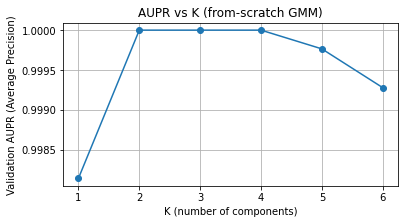

,K,val_ap
0,1,0.998143
1,2,1.000000
2,3,1.000000
3,4,1.000000
4,5,0.999765
5,6,0.999279


In [ ]:
# Q3: Cross-validate K on validation set using AUPR
from sklearn.metrics import average_precision_score

Ks = list(range(1,7))
results = {}

X_auth_train = X_train[y_train==0]
for K in Ks:
    print('Fitting K =', K)
    params = gmm_em(X_auth_train, K, max_iters=300, tol=1e-4, verbose=False)
    log_px_val = gmm_sample_loglikelihoods(X_val, params)
    # anomaly score = -log likelihood (higher score = more likely forged)
    scores = -log_px_val
    ap = average_precision_score(y_val, scores)
    results[K] = {'params':params, 'val_ap':ap, 'log_px_val':log_px_val}
    print('  Validation AUPR (average precision):', round(ap,4))

# Plot AUPR vs K
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(Ks, [results[K]['val_ap'] for K in Ks], marker='o')
plt.xlabel('K (number of components)')
plt.ylabel('Validation AUPR (Average Precision)')
plt.title('AUPR vs K (from-scratch GMM)')
plt.grid(True)
plt.show()

import pandas as pd
pd.DataFrame({'K':Ks, 'val_ap':[results[K]['val_ap'] for K in Ks]})


## Q4. Threshold Selection on Validation Set (4 Marks)

1. For the best K from Q4, determine an appropriate likelihood threshold using the authentic training likelihood distribution (e.g., percentile-based such as 5th percentile). **(2 Marks)**
2. Vary the threshold and compute Precision, Recall, and F1-score on the validation set. **(1 Mark)**
3. Choose the threshold that maximizes F1 and report it with its F1. **(1 Mark)**

---


In [ ]:
# Q4: Threshold selection for best K
from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support

# select best K by AUPR
best_K = max(results.keys(), key=lambda k: results[k]['val_ap'])
print('Best K by validation AUPR:', best_K, 'AUPR:', results[best_K]['val_ap'])

best_params = results[best_K]['params']

# compute log-likelihoods on authentic training samples
log_px_auth_train = gmm_sample_loglikelihoods(X_auth_train, best_params)

# show percentiles
percentiles = [1,5,10,25,50]
vals = np.percentile(log_px_auth_train, percentiles)
for p,v in zip(percentiles, vals):
    print(f'{p}th percentile of log-likelihood (auth train):', round(v,4))

# candidate thresholds based on percentiles of authentic training log-likelihoods
candidate_percentiles = list(range(1,51,2))
candidate_thresholds = np.percentile(log_px_auth_train, candidate_percentiles)

# Evaluate on validation set and compute F1 for each threshold
log_px_val = results[best_K]['log_px_val']
thresholds_eval = []
for thr in candidate_thresholds:
    preds = (log_px_val < thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds, average='binary', pos_label=1)
    thresholds_eval.append({'thr':thr, 'prec':prec, 'rec':rec, 'f1':f1})

import pandas as pd
df_thr = pd.DataFrame(thresholds_eval).sort_values('f1', ascending=False).reset_index(drop=True)
print('\nTop 5 thresholds by validation F1:')
display(df_thr.head())

# choose best threshold
best_row = df_thr.iloc[0]
best_threshold = best_row['thr']
best_f1_val = best_row['f1']
print('\nSelected threshold (max F1 on val):', round(best_threshold,6))
print('Validation F1 at selected threshold:', round(best_f1_val,4))


Best K by validation AUPR: 2 AUPR: 1.0000000000000002
1th percentile of log-likelihood (auth train): -8.1921
5th percentile of log-likelihood (auth train): -6.0562
10th percentile of log-likelihood (auth train): -4.8459
25th percentile of log-likelihood (auth train): -3.3924
50th percentile of log-likelihood (auth train): -2.5158

Top 5 thresholds by validation F1:


,thr,prec,rec,f1
0,-8.192090,0.989247,1.0,0.994595
1,-6.918903,0.978723,1.0,0.989247
2,-6.056195,0.938776,1.0,0.968421
3,-5.824345,0.929293,1.0,0.963351
4,-5.211579,0.876190,1.0,0.934010



Selected threshold (max F1 on val): -8.19209
Validation F1 at selected threshold: 0.9946


## Q5. Model Evaluation on Test Set (2 Marks)

1. Using the selected K and threshold, classify the test set samples as authentic or forged. **(1 Mark)**
2. Report Precision, Recall, and F1-score using ground truth labels. **(1 Mark)**
3. Display the confusion matrix for the test set.

---


From-scratch GMM on test set:
 Precision: 0.9891, Recall: 1.0000, F1: 0.9945

Confusion matrix (rows=true 0/1, cols=pred 0/1):
[[114   1]
 [  0  91]]


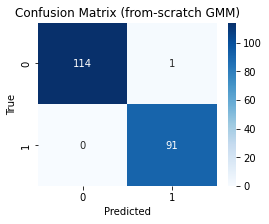

In [ ]:
# Q5: Evaluate on test set using chosen threshold
log_px_test = gmm_sample_loglikelihoods(X_test, best_params)

# classify
pred_test = (log_px_test < best_threshold).astype(int)

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
prec_t, rec_t, f1_t, _ = precision_recall_fscore_support(y_test, pred_test, average='binary', pos_label=1)
print('From-scratch GMM on test set:')
print(' Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(prec_t, rec_t, f1_t))

# confusion matrix
cm = confusion_matrix(y_test, pred_test)
print('\nConfusion matrix (rows=true 0/1, cols=pred 0/1):')
print(cm)

# show heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (from-scratch GMM)')
plt.show()


## Q6. Comparison with scikit-learn’s GMM (4 Marks)

1. Train `GaussianMixture` from `sklearn.mixture` using the best value of K and K-Means initialization. **(1 Mark)**
2. Repeat the threshold tuning on the validation set and compute Precision, Recall, and F1-score on the test set. **(1 Mark)**
3. Compare the results with your from-scratch GMM implementation (1 Mark).
4. Plot the log-likelihood distribution of authentic and forged samples and mark the selected threshold. Show this for both implementations and compare them. **(1 Mark)**

---


Top sklearn thresholds by validation F1:


,thr,prec,rec,f1
0,-8.168112,0.989247,1.0,0.994595
1,-6.933581,0.978723,1.0,0.989247
2,-6.036012,0.938776,1.0,0.968421
3,-5.802476,0.929293,1.0,0.963351
4,-5.233457,0.876190,1.0,0.934010


Selected sklearn threshold (val): -8.168112
Validation F1 at selected sklearn threshold: 0.9946

Sklearn GMM on test set:
 Precision: 0.9891, Recall: 1.0000, F1: 0.9945

Comparison:
 From-scratch -> Precision: 0.9891, Recall: 1.0000, F1: 0.9945
 Sklearn      -> Precision: 0.9891, Recall: 1.0000, F1: 0.9945


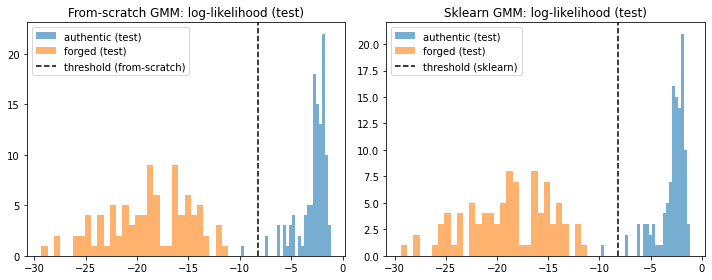


From-scratch means:
 [[ 0.77292261 -0.36967124  0.39306367  0.69903493]
 [ 0.57093898  1.1401487  -0.66649577 -0.681636  ]]

Sklearn means:
 [[ 0.7711443  -0.36112922  0.38784304  0.69813705]
 [ 0.57109252  1.14380684 -0.66984593 -0.69197486]]


In [ ]:
# Q6: sklearn GaussianMixture comparison
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_recall_fscore_support

# Fit sklearn GMM on authentic training data
gmm_sk = GaussianMixture(n_components=best_K, covariance_type='full', init_params='kmeans', random_state=RANDOM_STATE)
X_auth_train = X_train[y_train==0]
gmm_sk.fit(X_auth_train)

# compute log-likelihoods on validation and test
log_px_val_sk = gmm_sk.score_samples(X_val)
log_px_test_sk = gmm_sk.score_samples(X_test)

# Threshold tuning on validation
log_px_auth_train_sk = gmm_sk.score_samples(X_auth_train)
candidate_thresholds_sk = np.percentile(log_px_auth_train_sk, candidate_percentiles)

thresholds_eval_sk = []
for thr in candidate_thresholds_sk:
    preds = (log_px_val_sk < thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds, average='binary', pos_label=1)
    thresholds_eval_sk.append({'thr':thr, 'prec':prec, 'rec':rec, 'f1':f1})

import pandas as pd
df_thr_sk = pd.DataFrame(thresholds_eval_sk).sort_values('f1', ascending=False).reset_index(drop=True)
print('Top sklearn thresholds by validation F1:')
display(df_thr_sk.head())

best_row_sk = df_thr_sk.iloc[0]
best_threshold_sk = best_row_sk['thr']
print('Selected sklearn threshold (val):', round(best_threshold_sk,6))
print('Validation F1 at selected sklearn threshold:', round(best_row_sk['f1'],4))

# Evaluate on test
pred_test_sk = (log_px_test_sk < best_threshold_sk).astype(int)
prec_sk, rec_sk, f1_sk, _ = precision_recall_fscore_support(y_test, pred_test_sk, average='binary', pos_label=1)
print('\nSklearn GMM on test set:')
print(' Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(prec_sk, rec_sk, f1_sk))

# Compare to from-scratch
print('\nComparison:')
print(' From-scratch -> Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(prec_t, rec_t, f1_t))
print(' Sklearn      -> Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}'.format(prec_sk, rec_sk, f1_sk))

# Plot log-likelihood distributions and mark thresholds for both implementations
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(log_px_test[y_test==0], bins=30, alpha=0.6, label='authentic (test)')
plt.hist(log_px_test[y_test==1], bins=30, alpha=0.6, label='forged (test)')
plt.axvline(best_threshold, color='k', linestyle='--', label=f'threshold (from-scratch)')
plt.title('From-scratch GMM: log-likelihood (test)')
plt.legend()

plt.subplot(1,2,2)
plt.hist(log_px_test_sk[y_test==0], bins=30, alpha=0.6, label='authentic (test)')
plt.hist(log_px_test_sk[y_test==1], bins=30, alpha=0.6, label='forged (test)')
plt.axvline(best_threshold_sk, color='k', linestyle='--', label=f'threshold (sklearn)')
plt.title('Sklearn GMM: log-likelihood (test)')
plt.legend()
plt.tight_layout()
plt.show()

# Print means comparison
print('\nFrom-scratch means:\n', best_params['mu'])
print('\nSklearn means:\n', gmm_sk.means_)
